In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from PIL import Image
import os
import resource
import shutil
import zipfile
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

150.58203125

# Setting Up

## Useful Constants

In [2]:
epsilon_0 = 1 #8.854E-12 # F/m
mu_0 = 1 #np.pi*4.0E-7 # H/m
c = 1 #3.0E08 # m/s
n0 = 1.0 # Vacuum index of refraction
#lam0 = 450e-9+0.0j # m
#h0 = h1
#theta0 = np.pi/6
#h1 = 10e-9
#n1 = 1.5 # ~Plate glass index of refraction

# Unit vectors
e_x = np.array([1.0,0.0,0.0])
e_y = np.array([0.0,1.0,0.0])
e_z = np.array([0.0,0.0,1.0])
colors = ['b','orange','purple'] # Colourblind-friendly colours for plotting curves

## EM Wave

The refraction plane is the x-z plane, i.e. an s-polarised wave has the E field pointing along y and a p-polarised wave has the E field pointing along x and z (if not at normal incidence). In this study, we work only with normal incidence and s-polarisation for the sake of simplicity.

In [3]:
# Produces wavevector k from the wavenumber k_mag and angle of incidence theta w.r.t. normal to the plane parallel 
# optical elements
def k_vector(k_mag,theta=0): 
    return k_mag*np.array([np.sin(theta),0,np.cos(theta)])

# Takes wavevector ki and modifies its z-component as the wave propagates from a medium with index ni to one with nj.
# This is because the optical elements are assumed to be 1-dimensional and only vary in the z-direction
def k_j(ki,ni,nj):
    kj = np.array([ki[0],ki[1],np.sqrt(ki[2]**2+np.dot(ki,ki.conj())*((nj/ni)**2-1))])
    return kj

#ki0 = k_vector(np.array(2*np.pi/lam0),theta0)

## Optical System

Recall that the transfer (M) matrices are not causal. You do not have a simple physical input-output relation. You need to know the future in order to be able to use them. Meanwhile, the scattering (S) matrices are causal: you give input fields and get output fields.

### Elements and Periods

In [4]:
mirror_s = np.array([[1.0+0.0j,1.0e-9+0.0j],[1.0e-9+0.0j,1.0+0.0j]]) # Quasi-perfect mirror in S form

# Transform from transfer matrix (M) to scattering matrix (S)
def MtoS(mat):  
    [[m11,m12],[m21,m22]]=mat # Diagonal terms are reflection coefficients and off-diagonal are transmission coefficients
    [[r12,t21],[t12,r21]]=[[-m21/m22,1/m22],[m11-m12*m21/m22,m12/m22]]
    return np.array([[r12,t21],[t12,r21]])

# Tranform from scattering matrix (S) to transfer matrix (M)
def StoM(co):
    [[r12,t21],[t12,r21]]=co
    [[m11,m12],[m21,m22]]=[[(t12-r12*r21/t21),r21/t21],[-r12/t21,1/t21]]
    return np.array([[m11,m12],[m21,m22]])

# Layers (media and interfaces between them) are given in S form, transformed to M form for matrix multiplication and, in the 
# end, we get the total matrix for the group of layers in both M and S forms.
def totalSM(layers):
    m=np.identity(2) 
    for lay in layers:
        m0=StoM(lay)
        m=m0@m
    s=MtoS(m)
    return s,m

# Takes a k vector and produces the phase shift corresponding to propagation through an optical path h in the z-direction.
# S-form, diagonal terms are reflection coefficients.
def medium(k_vec,h):
    # k_vec is a 3D vector
    rij=0
    rji=0
    tij=np.exp(1j*k_vec[2]*h)
    tji=np.exp(1j*k_vec[2]*h)
    return np.array([[rij,tji],[tij,rji]])

# Scattering matrix, s-polarised. Uses the z-components of the input and output k vectors to produce the reflection and
# transmission coefficients.
def interface_s(ki,kj):
    kzi = ki[2]
    kzj = kj[2]
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
        return
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2)) # == 1 check that energy is conserved
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

# Produces the 5 component elements of a period (vacuum portion, interface s-pol., medium portion, interface s-pol., vacuum 
# portion) in S form, and the total S and M matrices. This is specific for s-polarisation. kj should already possess the 
# information on the refractive index of the medium portion while ki should correspond to a vacuum wavevector. hi gives the
# width of the vacuum portion while hj gives the width of the medium portion.
def period_s(ki,kj,hi,hj):
    layers_s =[medium(ki,hi/2),interface_s(ki,kj),medium(kj,hj),interface_s(kj,ki),medium(ki,hi/2)]
    ss,ms = totalSM(layers_s)
    #print(np.abs(ss[0][0])**2+np.abs(ss[0][1])**2) # == 1 check that energy is conserved
    #print(np.abs(ss[1][0])**2+np.abs(ss[1][1])**2)
    return ss,ms,layers_s

### Effectives

In [5]:
# Finds the forward propagating eigenvalue of a period in M form and, by treating it as a phase shift and scaling it with the
# phase shift in the medium part, finds a delta n between the medium index of refraction and the effective index of refraction
# for the whole period. Subtracting this from n gives neff, which makes sense as it should be slightly smaller than n.
# h is the total width of the period and r (called the width ratio) is the fraction over 1 of the vacuum portion width relative
# to the total width.
def eff_n(ki,n,h,r):
    kj = k_j(ki,n0,n)
    perM = period_s(ki,kj,h*r,h*(1-r))[1]
    evs = np.linalg.eig(perM)[0][0] # Takes only the forward propagating eigenvalue
    neff = n + np.real(np.log(evs/np.exp(1j*h*kj[2]))/(1j*ki[2]*h))
    return neff

# Finds the index of refraction the medium part of a period should have for the whole period (and thus the crystal it belongs
# to) to have neff given period width h, width ratio r, and an incident k vector ki. This is tailored for s-polarisation.
def reverse_eff_n(ki,neff,h,r):
    n_s = 0
    def find_n_s(n):
        return eff_n(ki,n,h,r)-neff
    n_s = root_scalar(find_n_s, bracket=[1,2*neff]).root
    return n_s

### Composite Structure

In [20]:
# For a series of medium portion refractive indices n_m, period widths h, and width ratios r, it creates all the S matrices 
# (5 per n_m, h, and r uniquely defining a period) that a plane wave with vector ki would interact with. It appends all the 
# layers in S form into the array elementss_decomp, and the total S matrix for each period in the array elementss.
def element_maker(ki,refrac_indices,widths,width_ratios):
    elementss = []
    elementss_decomp = []
    for i in range(len(refrac_indices)):
        kj = k_j(ki,n0,refrac_indices[i])
        hi = width_ratios[i]*widths[i]
        hj = (1-width_ratios[i])*widths[i]
        ss,ms,layers_s = period_s(ki,kj,hi,hj)
        elementss.append(ss)
        elementss_decomp.append(layers_s)
    return elementss,elementss_decomp

# Takes the different types of periods (or corresponding composing layers) we want our EM wave to interact with (in S form)
# and the numbers of periods and concatenates them. So if we have periods p1,p2,p3 of which there are n1,n2,n3, this 
# concatenates n1*p1,n2*p2,n3*p3 creating a structure of lengt n1+n2+n3 periods of 5*(n1+n2+n3) layers depending on whether we
# use elementss or elementss_decomp from above.
def embedded_structure(elements_s_form,num_elements):
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = np.tile(elements_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_s_form[i], (num_elements[i], 1, 1))))
    return emb

# Produces a DBR structure designed to work as a mirror. This returns its decomposed form (5 elements per period).
def DBR_structure(k_DBR,n_DBR,num_layers,theta=0):
    ki = k_vector(k_DBR,theta)
    lambda_DBR = 2*np.pi/k_DBR
    layers_DBR = period_s(ki,k_j(ki,n0,n_DBR),lambda_DBR/8,lambda_DBR/(4*n_DBR))[2] #m_DBR,
    return np.tile(layers_DBR, (num_layers, 1, 1))

# Visually tests that, for a characteristic wavevector km, and medium portion refractive index n_DBR, this structure fully 
# reflects the incident pulse wave composed of waves with wavenumbers k_values.
def test_DBR(n_DBR,km,k_values):
    ki = k_vector(km,0)
    kj = k_j(ki,n0,n_DBR)
    lambda_m = 2*np.pi/km
    m = period_s(ki,kj,lambda_m/8,lambda_m/(4*n_DBR))[1]
    array = np.empty((len(k_values),2))
    for i in range(len(k_values)):
        k = k_values[i]
        ki = k_vector(k,0)
        kj = k_j(ki,n0,n_DBR)
        m = period_s(ki,kj,lambda_m/8,lambda_m/(4*n_DBR))[1]
        array[i] = np.abs(np.linalg.eig(m)[0])   
    plt.figure()
    plt.title('Eigenvalues as a Function of Wavenumber in the DBR')
    plt.xlabel('Wavenumber (m^-1)')
    plt.ylabel('Modulus of Eigenvalue')
    plt.plot(k_vals,array)
    plt.show()

## Fields

In [7]:
# Selects the forward propagating eigenvector of the M matrix of a period. The purpose of this is to find the output field at 
# the right-hand end of an optical system assuming that the system is infinite after that with the same characteristics 
# meaning that there should be no back reflection.
def semi_inf_prop(mMat):
    U_T = np.linalg.eig(mMat)[1]
    if np.abs(U_T[0][0]) > np.abs(U_T[1][0]):
        return U_T[0]
    else:
        return U_T[1]

# By looking at the eigenvalues, it selects the evanescent one and returns the corresponding eigenvector. This is done so that
# when applied to a mirror the transmission tends to 0 and we have total reflection after a few layers of a DBR.
def evanescent_evec(mMat):
    vals,U_T = np.linalg.eig(mMat)
    if np.abs(vals[0]) > np.abs(vals[1]):
        return U_T[1]
    else:
        return U_T[0]

# Produces the output eigenvector given the last element in an embedded structure (could be a crystal or a DBR mirror) and
# backpropagates it through an embedded structure (inverting the M matrices along the way) to get the amplitudes of the 
# forward and backward propagating (s-polarised) modes at every element (vacuum, interface, medium, etc.) and normalises
# everything with respect to the forward propagating mode amplitude at the very start of the structure so that the initial
# phase is 0 and then multiplies everything by a0_pol - the hypothetical input amplitude at the origin of this propagation.
def amps_from_emb_pol(a0_pol,emb,DBR_exist):
    last_per = totalSM(emb[-5:])[1]
    aibi_pol = np.empty((len(emb)+1,2),dtype=np.complex64) # Larger than emb by 1 because we also want to include the output
    # vector.
    if DBR_exist:
        anbn_pol = evanescent_evec(last_per) # DBR evanescent eigenvector
    else:
        anbn_pol = semi_inf_prop(last_per) # Assume infinite propagation through a medium identical to the last in the 
        # system
    aibi_pol[-1] = anbn_pol
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoM(emb[i]))@m # Backpropagation
        aibi_pol[i] = m@(anbn_pol)
    return np.transpose(aibi_pol/aibi_pol[0][0])*np.abs(a0_pol) # a0_pol already has the right units

# For every k vector, an embedded structure is produced and the amplitudes at each position of the structure are generated and
# stored. The factor of 5 is necessary as we have 5 times as many components as there are periods and we are choosing to get 
# the amplitudes for each component rather than only at or after each whole period (necessary for interface discontinuities
# and average acting fields). The +1 is there because, as above, we will have one last amplitude vector corresponding to the 
# output (eigen)vector.
def amps_from_emb_pol_multi_k(a0_pol,k_values,n_ms,hs,rs,num_pers,theta,DBR_els,n_DBR_pers,DBR_exist):
    ai_pol_k = np.empty((len(k_values),5*(np.sum(num_pers)+n_DBR_pers)+1),dtype=np.complex64)
    bi_pol_k = np.empty((len(k_values),5*(np.sum(num_pers)+n_DBR_pers)+1),dtype=np.complex64)
    for i in range(len(k_values)):
        ki = k_vector(k_values[i],theta) # Loop over each wavenumber
        elementss_decomp = element_maker(ki,n_ms,hs,rs)[1]
        emb = embedded_structure(elementss_decomp,num_pers)
        emb = np.concatenate((emb,DBR_els)) # If there is a DBR, add it at the end to already existing structure
        [ai_pol,bi_pol] = amps_from_emb_pol(a0_pol,emb,DBR_exist)
        ai_pol_k[i,:] = ai_pol
        bi_pol_k[i,:] = bi_pol
    return ai_pol_k,bi_pol_k

# Creates a Gaussian envelope to weight the plane wave components as a function of their wavevectors
def gaussian_weighting(k_values, k_c=5, sigma=1.5):
    return 1/(np.sqrt(2*np.pi)*sigma)*np.exp(-0.5 * ((k_values - k_c) / sigma)**2)

# Creates a time-varying complex exponential modulation which depends on k so it will be different for each of the 
# plane waves
def time_mod(k_values, t_values):
    return np.exp(-1j * np.outer(k_values, t_values) * c)

# Computes the magnetic fields vectors at different positions and moments in time by taking the cross-product of the 3D 
# electric fields with their corresponding wavevectors for each of the component plane waves and integrating (i.e. adding) 
# over the wavevectors. The code is made faster by considering that H = \mu \ \omega * k_vec x E_vec but omega = c*k and 
# k_vec \ k = direction unit vector. Thus, we only need to take the cross-product with the directional unit vectors (which are
# the same for a given theta and propagation direction) instead of with individual wavevectors.
def mag_field_t(ai_3d_multi_tk,bi_3d_multi_tk,theta=0):
    au_dir = (np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex64))
    bu_dir = (np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex64))
    shape = np.shape(ai_3d_multi_tk)
    Hi_3d_multi_t = np.empty((shape[0],shape[2],shape[3]),dtype=np.complex64)
    for t in range(shape[0]):
        for p in range(shape[2]):
            Hi_3d_multi_t[t][p] = np.sum(np.cross(au_dir,ai_3d_multi_tk[t][:,p])+np.cross(bu_dir,bi_3d_multi_tk[t][:,p]),axis=0)
    return -1 /(mu_0*c) * Hi_3d_multi_t

# Turns the s-polarised field amplitudes into 3D vectors
def sto3d_multi_tk(ai_pol_tk):
    return np.einsum('jkl,i->jkli', ai_pol_tk, e_y)

# This modulates the amplitudes produced by amps_from_emb_pol_multi_k and produces the 3D electric and magnetic fields at each
# position and moment in time.
def amps_fields_from_emb_pol_multi_tk(a0_pol,k_values,t_values,n_ms,hs,rs,num_pers,theta=0,
                                      k_c=5,sigma=1.5,km_DBR=6.9,n_DBR=20,n_DBR_pers=0):
    weights_tk = np.einsum('ik,i->ki',time_mod(k_vals,t_vals2),gaussian_weighting(k_vals))
    #np.transpose(gaussian_weighting(k_values[:,np.newaxis],k_c,sigma)*time_mod(k_values,t_values))
    DBR_els = DBR_structure(km_DBR,n_DBR,n_DBR_pers,theta)
    DBR_exist = False
    if n_DBR_pers > 0:
        DBR_exist = True
    ai_pol_k,bi_pol_k = amps_from_emb_pol_multi_k(a0_pol,k_values,n_ms,hs,rs,num_pers,theta,DBR_els,n_DBR_pers,DBR_exist)
    norm = np.sum(np.abs(weights_tk[0])) # Normalises so that when we integrate over k the maximum pulse 
    # amplitude is 1
    ai_pol_tk = np.einsum('ij,jk->ijk',weights_tk,ai_pol_k)/norm
    bi_pol_tk = np.einsum('ij,jk->ijk',weights_tk,bi_pol_k)/norm
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    ai_pol_t = np.sum(ai_pol_tk,axis=1) # Integrate k away
    bi_pol_t = np.sum(bi_pol_tk,axis=1)
    Ei_3d_t = np.sum(ai_3d_multi_tk+bi_3d_multi_tk,axis=1) # Fields result from the interaction of the forwards and backwards
    # propagating fields
    Hi_3d_t = mag_field_t(ai_3d_multi_tk,bi_3d_multi_tk,theta)
    return ai_pol_t,bi_pol_t,Ei_3d_t,Hi_3d_t

# Plots the intensities of the forward propagating, backward propagating, and combined modes for a fixed time at different 
# positions in the optical system.
def plot_amps(ai,bi,time,num_els,cols=colors,top_y=1,bottom_y=0):
    plt.figure()
    edges = np.cumsum(np.array(num_els))
    xvals = np.arange(0,edges[-1],1)
    edgelocs = np.array([0, num_els[0]])
    for i in range(len(num_els)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_els[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'Intensity Across Layers t = {time} time units')
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    for n in range(len(num_els)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,np.abs(ai)**2, label='|a|^2')
    plt.plot(xvals,np.abs(bi)**2, label='|b|^2')
    plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2')
    plt.ylim(-0.02,1.02)
    plt.legend()
    plt.grid()
    plt.show()

## Momentum

In [8]:
# Takes one 3D electric field vector and one 3D magnetic field and computes their stress tensor. Always evaluated in vacuum,
# which is why we get away with using epsilon_0 and mu_0. We employ time-averaging as we are dealing with complex plane waves.
def stress_tensor(Ei_3d,Hi_3d):
    E_ij = 0.5 * epsilon_0 * (np.tensordot((Ei_3d).conj(),(Ei_3d),axes=0) \
                              + np.tensordot((Ei_3d),(Ei_3d).conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot((Ei_3d).conj(),(Ei_3d)) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot((Hi_3d).conj(),(Hi_3d),axes=0) \
            + np.tensordot((Hi_3d),(Hi_3d).conj(),axes=0)) - \
            0.5 * mu_0 * np.dot((Hi_3d).conj(),(Hi_3d)) * np.eye(3)
    return E_ij + H_ij

# Loops through the different time and position values of the Ei_3d_t and Hi_3d_t arrays to compute the stress tensor at each
# pair of these. This was more efficient than using np.einsum surprisignly.
def stress_tensor_t(Ei_3d_t,Hi_3d_t):
    t_len,pos_len = np.shape(Ei_3d_t)[:2]
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex64)
    for t in range(t_len):
        for p in range(pos_len):
            st_pol_t_pos[t][p] = stress_tensor(Ei_3d_t[t][p],Hi_3d_t[t][p])
    return st_pol_t_pos

# Produces the Poynting vector at different positions and times
def Poynting_vector_t_pos(Ei_3d_t,Hi_3d_t):
    return 0.5*(np.cross(Ei_3d_t,Hi_3d_t.conj())+np.cross(Ei_3d_t.conj(),Hi_3d_t))

# Projects the stress tensor at a given position and time onto the z-direction to obtain the momentum flux in the z-direction
def z_momentum_flux(stress_tensor_tp):
    return np.real(np.einsum("jklm,l,m->jk",stress_tensor_tp,e_z,e_z))

# This takes the difference between consecutive momentum fluxes in vacuum in the z-direction to find the momentum flux in the
# medium portions of the periods, i.e. the force surface densities in the z-direction, and plots them but allowing subplot 
# manipulation to also plot the total accumulated impulse surface densities in the z-direction.
def plot_z_momentum(z_momentum_flux, time, num_elements):
    int_locs = np.cumsum(np.array(num_elements))[:-1]
    plt.figure()
    p = plt.subplot(1,1,1)
    p.set_xlabel('Layer Number')
    p.set_ylabel('Z-Force Density')
    p.set_title(f'Z-Force Density Across Layers t = {time} time units')
    p.plot(np.diff(z_momentum_flux))
    for loc in int_locs:
        p.axvline(loc,ls='--',c='k')
    p.grid()
    return p

# Same as above but more sophisticated
def plot_z_force_density(z_mom_flux_pos,time,num_elements,vals0,top_y=1,bottom_y=-0.6):
    plt.figure()
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)
    edgelocs = np.array([0, num_elements[0]-0.5])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i]-0.5,edges[i]-0.5+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=colors[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc-0.5,ls='--',c='k')
    plt.xlabel('Layer Number')
    plt.ylabel('Force Density')
    plt.title(f'Z-Force Density Across Layers t = {time} time units')
    plt.plot(xvals,f_dens_pos,label='Z-Force Density')
    plt.plot(xvals,vals0,label= f'Total Impulse at t = {time} time units')
    plt.ylim(-0.62,1.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals0+=f_dens_pos
    plt.show()
    return vals0

## Forces on Interfaces

In [9]:
# Computes the charge and current surface densities at each interface (between vacuum and medium portions so there are two per
# period) from the discontinuities of the electric and magnetic fields at either side, and the effective electric and 
# magnetic fields from the average of their values at both sides of each interface as suggested by Griffith's paper.
def surface_charges_currents_t(Ei_3d_t,Hi_3d_t,num_elements,refrac_indices):
    indices_to_remove = np.arange(0, Ei_3d_t.shape[1], 5)
    # We remove the first element of each 5 optical elements (decomposed periods) as this just corresponds to the value
    # in the vacuum between periods.
    Di_3d_t_ints = np.delete(Ei_3d_t, indices_to_remove, axis=1)
    Ei_3d_t_ints = np.delete(Ei_3d_t, indices_to_remove, axis=1)
    Hi_3d_t_ints = np.delete(Hi_3d_t, indices_to_remove, axis=1)
    # Only half as many positions because from the values of the electric fields before and after an interface only comes out
    # one charge surface density value. The same is true for the current surface densities.
    charges_t = np.empty((len(Di_3d_t_ints),Di_3d_t_ints.shape[1]//2),dtype=np.complex64)
    # Currents and fields have 3D vector components while the charges are scalars.
    currents_t = np.empty((len(Hi_3d_t_ints),Hi_3d_t_ints.shape[1]//2,3),dtype=np.complex64)
    E_acting_t =  np.empty((np.shape(currents_t)),dtype=np.complex64)
    H_acting_t =  np.empty((np.shape(currents_t)),dtype=np.complex64)
    nums = np.hstack(([0],np.array(num_elements)))
    for i in range(len(refrac_indices)):
        n = refrac_indices[i]
        # We consider our media to only be polarisable but not magnetisable so mu_0 can remain the same but epsilon must be
        # changed with the refractive index.
        e = epsilon_0*n**2
        for j in range(nums[i+1]):
            Di_3d_t_ints[:,nums[i]+j] = epsilon_0*Di_3d_t_ints[:,nums[i]+j]
            Di_3d_t_ints[:,nums[i]+2*j] = e*Di_3d_t_ints[:,nums[i]+2*j]
            Di_3d_t_ints[:,nums[i]+3*j] = e*Di_3d_t_ints[:,nums[i]+3*j]
            Di_3d_t_ints[:,nums[i]+4*j] = epsilon_0*Di_3d_t_ints[:,nums[i]+4*j]
    for k in range(charges_t.shape[1]):
        charges_t[:,k] = (Di_3d_t_ints[:,2*k+1] - Di_3d_t_ints[:,2*k])@e_z
        currents_t[:,k] = np.cross(e_z,(Hi_3d_t_ints[:,2*k+1] - Hi_3d_t_ints[:,2*k]))
        E_acting_t[:,k] = (Ei_3d_t_ints[:,2*k+1] + Ei_3d_t_ints[:,2*k])/2
        H_acting_t[:,k] = (Hi_3d_t_ints[:,2*k+1] + Hi_3d_t_ints[:,2*k])/2
        # The code commented out is useful for trying expressions for B and E different to the averaged ones.
        #if k%2 == 1:
        #    B_acting[:,k] = mu_0 * Hi_3d_t_ints[:,2*k+1]
        #else:
        #    B_acting[:,k] = mu_0 * Hi_3d_t_ints[:,2*k]
    return charges_t,currents_t,E_acting_t,mu_0 * H_acting_t #mu_0 * H = B

# Computes the Lorentz force at different positions in the system and times
def Lorentz_force_t(charges_t,currents_t,E_acting_t,B_acting_t):
    return np.real(np.einsum('ij,ijk->ijk',charges_t,E_acting_t.conj()) + np.cross(currents_t,B_acting_t.conj()))
    #return 0.5*(np.einsum('ij,ijk->ijk',charges_t,E_acting_t.conj()) + np.einsum('ij,ijk->ijk',charges_t.conj(),E_acting_t) + \
     #           np.cross(currents_t,B_acting_t.conj()) + np.cross(currents_t.conj(),B_acting_t))

# Computes the total Lorentz force acting on the medium portion of a single period for different times and positions.
# This is essentially the mechanical flow of momentum into the medium portions (here called layers).
def layer_forces_t(L_forces_t):
    layerforces_t = np.empty((np.shape(L_forces_t)[0],np.shape(L_forces_t)[1]//2),dtype=np.complex64)
    for i in range(np.shape(L_forces_t)[1]//2):
        layerforces_t[:,i] = np.einsum('j,ij->i',e_z,L_forces_t[:,2*i+1] + L_forces_t[:,2*i])
    return np.real(layerforces_t)

# Plots the forces acting on the medium portions (layers).
def plot_layerforces(layerforces,time,num_elements,cols=colors,top_y=1,bottom_y=-1.5):
    plt.figure()
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(1,len(vacforces)+1,1)
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'Lorentz Z-Force Densities on Vacuum Elements Across Layers t = {time} time units')
    plt.xlabel('Layer Number')
    plt.ylabel('Force Density')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,vacforces,c=cols[0])
    plt.ylim(-1.52,1.02)
    #plt.legend()
    plt.grid()
    plt.show()

# What next?

1. Poynting vector time dependence (needs velocity estimation with Gaussian fit)
2. MST includes some energy of the pulse itself which is a conserving quantity (quadratic in the field) and once it leaves its the same as Lorentz
3. Energy dissapears once the pulse has left

Pulse comes in, reflects, gets to mirror, exits structure, structure left with 2xp_0.
Lorentz forces look at interface interactions while MST looks at bulk interactions (pulse leaves or enters system).
The difference between A and M is somewhere between these two versions.
MomEnT only defined up to a divergence-free field i.e. we can add sigma prime as long as its div is 0.
Clarify the difference between impulse left behind and momentum (collsion between pulse and layers).
Variation in locally defined forces can be explained through the non-uniqueness of the ST with no effect on the long term limit.
L. Force says induce suface density ch and act on it to create a force dens
MST gives an overall impulse

# Working

What determines the field?
1. The input amplitudes a0,b0 (obtained from a0, ki and system)
2. The incidence wavevector ki
3. The media elements determined by nj,r,h

## System Specs

In [10]:
def gr

SyntaxError: expected '(' (4259994877.py, line 1)

In [22]:
kc

7.01

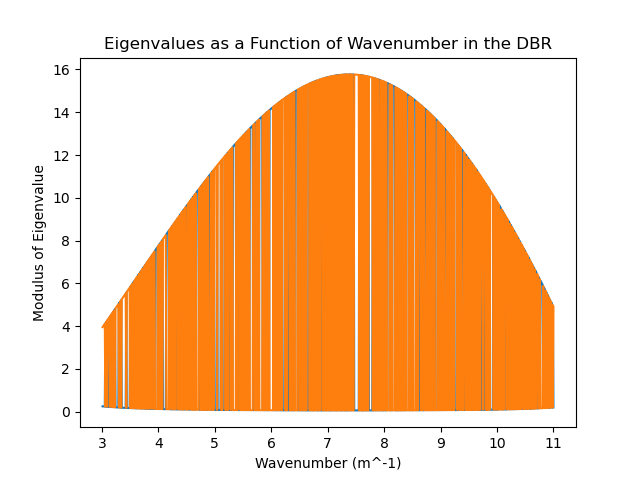

In [21]:
n_DBR = 20 # Refractive index of the DBR layers
n_DBR_pers = 5 # Number of DBR periods
k_vals = np.arange(0.01, 8.01, 0.01) + 3 # Wavenumber values for the pulse. The corrsponding wavelengths are (often much)
# larger than the periods widths used so that variation within a period is minimised.
kc = k_vals[len(k_vals)//2] # Central wavenumber value. Necessary for the Gaussian weighting
km_DBR = k_vals[int(len(k_vals)//2.7)] # The wavenumber used to determine the DBR period width. This is obtained through a
# visual test executing the lines below. The goal is to get non-unity eigenvalues for our array of wavenumbers by tweaking
# n_DBR and km_DBR
#DBR = DBR_structure(km_DBR,n_DBR,n_DBR_pers)
#print(km)
test_DBR(20,km_DBR,k_vals)
#k_vals2 = np.arange(0.01, 10.01, 0.01)

# Time values for simulation. The time step is also used for integrating the momentum flux. A very small time step is needed in
# order to reduce numerical errors in the integration and to maximise smoothness of the animations
t_step = .05
t_vals = np.arange(-2.0, 190.0, t_step)
t_vals2 = np.arange(-2.0, 120.0, t_step)
t_vals3 = np.arange(-2.0, 190.0, .5)

# The width of period types a,b and c
ha = .2
hb = .2
hc = .2

# The fraction out of 1 of the vacuum portions of period types a,b and c
ra = 0.01
rb = 0.01
rc = 0.01

# The effect refractive indices of the crystals we are working with
n_effa = n0 # This is just vacuum
n_effb = 1.5 # E.g. ~ window glass
n_effc = 2.5 # This is fictitious

# The refractive indices of the medium portions of period types a,b and c
na = reverse_eff_n(k_vector(kc),n_effa,ha,ra) # = 1.0
nb = reverse_eff_n(k_vector(kc),n_effb,hb,rb) # = 1.504
nc = reverse_eff_n(k_vector(kc),n_effc,hc,rc) # = 2.51

# Vacuum + DBR
n_ms = [na]
hs = [ha]
rs = [ra]
nums = [100] # Number of periods in a crystal
numsb = [20]
colors_med = ['blue'] # For plotting the crystals

# Vacuum + crystal + crystal + DBR
n_ms1 = [na,nb,nc]
hs1 = [ha,hb,hc]
rs1 = [ra,rb,rc]
nums1 = [100,50,50] # Number of DBR periods not included as the code appends it additionally when given the right input
nums1b = [15,20,20]
colors_med1 = ['blue','red','green']

# Vacuum + crystal + crystal + vacuum
n_ms2 = [na,nb,nc,na]
hs2 = [ha,hb,hc,ha]
rs2 = [ra,rb,rc,ra]
nums2 = [100,50,50,100]
nums2b = [15,20,20,n_DBR_pers] # We want the same number of DBR and vacuum periods to compare like with like
colors_med2 = ['blue','red','green','blue']

## Execution

In [ ]:
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

In [ ]:
%%time
# Vacuum + DBR
ai_pol_t,bi_pol_t,Ei_3d_t,Hi_3d_t = amps_fields_from_emb_pol_multi_tk(1,k_vals,t_vals2,n_ms,hs,rs,numsb,k_c=kc,km_DBR=km_DBR,n_DBR=n_DBR,n_DBR_pers=n_DBR_pers)

In [ ]:
%%time
# Optical system + DBR
ai_pol_t1,bi_pol_t1,Ei_3d_t1,Hi_3d_t1 = amps_fields_from_emb_pol_multi_tk(1,k_vals,t_vals2,n_ms1,hs1,rs1,nums1b,k_c=kc,km_DBR=km_DBR,n_DBR=n_DBR,n_DBR_pers=n_DBR_pers)

In [ ]:
%%time
# Optical system + no DBR
ai_pol_t2,bi_pol_t2,Ei_3d_t2,Hi_3d_t2 = amps_fields_from_emb_pol_multi_tk(1,k_vals,t_vals2,n_ms2,hs2,rs2,nums2b,k_c=kc)

In [ ]:
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

## Intensity

In [ ]:
# Every 5th element corresponds to the vacuum region between consecutive periods. This includes the edges between consecutive
# crystals.
step = 5
a_t_pos = ai_pol_t[:,::step]
b_t_pos = bi_pol_t[:,::step]
a_t_pos1 = ai_pol_t1[:,::step]
b_t_pos1 = bi_pol_t1[:,::step]
a_t_pos2 = ai_pol_t2[:,::step]
b_t_pos2 = bi_pol_t2[:,::step]
np.shape(a_t_pos1)
np.shape(a_t_pos2)

### Plot

In [ ]:
#for t in range(len(t_vals)//2):
#    plot_amps(a_t_pos[2*t][:-11],b_t_pos[2*t][:-11],t_vals[2*t],nums3b)

## Momentum Flux

In [ ]:
%%time
# Only want every 5th element as we want the MSTs at the vacuum parts between periods and use the values there to do a
# "surface integral" (project along z as this is a 1D problem) and obtain the momentum flux in the medium portions
stt_vac = stress_tensor_t(Ei_3d_t[:,::step],Hi_3d_t[:,::step])
stt1 = stress_tensor_t(Ei_3d_t1[:,::step],Hi_3d_t1[:,::step])
stt2 = stress_tensor_t(Ei_3d_t2[:,::step],Hi_3d_t2[:,::step])

In [ ]:
# These are the Poynting vectors at the vacuum portions, not yet in the medium portions
Poynvec1 = Poynting_vector_t_pos(Ei_3d_t1[:,::step],Hi_3d_t1[:,::step])
Poynvec2 = Poynting_vector_t_pos(Ei_3d_t2[:,::step],Hi_3d_t2[:,::step])

# The next two steps perform the "surface integral" centred at the medium portion of each period
z_mom_flux_t_pos_vac = z_momentum_flux(stt_vac)
z_mom_flux_t_pos1 = z_momentum_flux(stt1)
z_mom_flux_t_pos2 = z_momentum_flux(stt2)

f_dens_t_pos_vac = np.diff(z_mom_flux_t_pos_vac,axis=1)
f_dens_t_pos1 = np.diff(z_mom_flux_t_pos1,axis=1)
f_dens_t_pos2 = np.diff(z_mom_flux_t_pos2,axis=1)

print(np.shape(Poynvec1))
print(np.shape(Poynvec2))

print(np.shape(z_mom_flux_t_pos_vac))
print(np.shape(z_mom_flux_t_pos1))
print(np.shape(z_mom_flux_t_pos2))

print(np.shape(f_dens_t_pos_vac))
print(np.shape(f_dens_t_pos1))
print(np.shape(f_dens_t_pos2))

### Plot

In [ ]:
#vals0 = np.zeros((len(z_mom_flux_t_pos[0])-1))
#for t in range(len(t_vals)):
#    p = plot_z_momentum(z_mom_flux_t_pos[t],t_vals[t],nums1)
#    vals0=vals0+np.diff(z_mom_flux_t_pos[t])
#    p.plot(vals0)
#    plt.show()
#    plt.close()

## Forces on Interfaces

In [ ]:
%%time
# We want this at the interfaces within periods, not at the vacuum between periods
charges_t_vac,currents_t_vac,E_acting_t_vac,B_acting_t_vac = surface_charges_currents_t(Ei_3d_t,Hi_3d_t,numsb,n_ms)
charges_t1,currents_t1,E_acting_t1,B_acting_t1 = surface_charges_currents_t(Ei_3d_t1,Hi_3d_t1,nums1b,n_ms1)
charges_t2,currents_t2,E_acting_t2,B_acting_t2 = surface_charges_currents_t(Ei_3d_t2,Hi_3d_t2,nums2b,n_ms2)

L_forces_t_vac = Lorentz_force_t(charges_t_vac,currents_t_vac,E_acting_t_vac,B_acting_t_vac)
L_forces_t1 = Lorentz_force_t(charges_t1,currents_t1,E_acting_t1,B_acting_t1)
L_forces_t2 = Lorentz_force_t(charges_t2,currents_t2,E_acting_t2,B_acting_t2)

layerforces_t_vac = layer_forces_t(L_forces_t_vac)
layerforces_t1 = layer_forces_t(L_forces_t1)
layerforces_t2 = layer_forces_t(L_forces_t2)

print(np.shape(L_forces_t_vac))
print(np.shape(L_forces_t1))
print(np.shape(L_forces_t2))
print(np.shape(layerforces_t_vac))
print(np.shape(layerforces_t1))
print(np.shape(layerforces_t2))

### Plot

In [ ]:
#for t in range(len(t_vals)):
#    plot_layerforces(layerforces_t[t],t_vals[t],nums2b)

# Animation

In [ ]:
def delete_content(str_folder_name):
    !rm $str_folder_name/* 

In [ ]:
#def gr

## Intensity

### Functions

In [ ]:
def generate_plot_amps(ai,bi,time,num_elements,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(ai),1)
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,np.abs(ai)**2, label='|a|^2')
    plt.plot(xvals,np.abs(bi)**2, label='|b|^2')
    plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2')
    plt.title(f'Intensity Across Layers t = {time:.2f} time units')
    plt.xlabel('Position (layer number)') # A layer starts at the vacuum half before the medium portion
    plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend()
    plt.grid()
    return plt.gcf()

def anim_amps(filename,a_t_pos,b_t_pos,t_values,num_elements,cols_med,n_DBR_pers=0):
    time_frame = len(t_values)
    os.makedirs(filename, exist_ok=True)
    for t in range(time_frame):
        fig = generate_plot_amps(a_t_pos[t],b_t_pos[t],t_values[t],num_elements,cols_med=cols_med,n_DBR_pers=n_DBR_pers)
        fig.savefig(filename+f'/plot_amps{t:03d}.png')
        plt.close(fig)
    zip_filename = filename + '.zip'
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for t in range(time_frame):
            zipf.write(filename + f'/plot_amps{t:03d}.png', f'plot_amps{t:03d}.png')
    images = [Image.open(filename+f'/plot_amps{t:03d}.png') for t in range(time_frame)]
    images[0].save(filename+'/amps_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
%%time
delete_content('anim_amps1')
anim_amps('anim_amps1',a_t_pos1,b_t_pos1,t_vals2,nums1b,colors_med1,n_DBR_pers=n_DBR_pers)

In [ ]:
%%time
delete_content('anim_amps2')
anim_amps('anim_amps2',a_t_pos2,b_t_pos2,t_vals2,nums2b,colors_med2)

## Momentum Flux (Differential i.e. in Medium Parts)

### Functions

In [ ]:
def generate_plot_sttforcez(f_dens_pos,time,num_elements,vals0,n_DBR_pers=0,cols_med=colors_med1,top_y=1,bottom_y=-0.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse SD (arb. units)')
    plt.title(f'(MST) Z-Force Surface Densities (SD) on Layers t = {time:.2f} time units')
    plt.plot(xvals,f_dens_pos,label='(MST) Z-Force SD')
    plt.plot(xvals,vals0,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend()#loc='upper left')
    plt.grid()
    vals0+=f_dens_pos*t_step
    return plt.gcf(),vals0

def anim_sttforcez(filename,f_dens_t_pos,t_values,num_elements,cols_med,n_DBR_pers=0,top_y=2.7,bottom_y=-1.5):
    vals0 = np.zeros((len(f_dens_t_pos[0])))
    time_frame = len(t_values)
    os.makedirs(filename, exist_ok=True)
    for t in range(time_frame):
        fig,vals0 = generate_plot_sttforcez(f_dens_t_pos[t],t_values[t],num_elements,vals0,n_DBR_pers=n_DBR_pers,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(filename+f'/plot_sttforcez{t:03d}.png')
        plt.close(fig)
    zip_filename = filename + '.zip'
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for t in range(time_frame):
            zipf.write(filename + f'/plot_sttforcez{t:03d}.png', f'plot_sttforcez{t:03d}.png')
    images = [Image.open(filename+f'/plot_sttforcez{t:03d}.png') for t in range(time_frame)]
    images[0].save(filename+'/asttforcez_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_sttforcez1')
anim_sttforcez('anim_sttforcez1',f_dens_t_pos1,t_vals2,nums1b,colors_med1,n_DBR_pers=n_DBR_pers)

In [ ]:
delete_content('anim_sttforcez2')
anim_sttforcez('anim_sttforcez2',f_dens_t_pos2,t_vals2,nums2b,colors_med2)

## Lorentz Forces on Medium Parts

### Functions

In [ ]:
def generate_plot_lorentzforcez(layerforces,time,num_elements,vals1,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(layerforces),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Z-Force Surface Densities (SD) on Layers t = {time:.2f} time units')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse SD (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,layerforces,label='(Lorentz) Z-Force SD')
    plt.plot(xvals,vals1,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.grid()
    vals1+=layerforces*t_step
    plt.legend()#loc='upper left')
    return plt.gcf(),vals1

def anim_lorentzforcez(filename,layerforces_t,t_values,num_elements,cols_med,n_DBR_pers=0,top_y=2.7,bottom_y=-1.5):
    time_frame = len(t_values)
    vals1 = np.zeros((np.shape(layerforces_t)[1]))
    os.makedirs(filename, exist_ok=True)
    for t in range(time_frame):
        fig,vals1 = generate_plot_lorentzforcez(layerforces_t[t],t_values[t],num_elements,vals1,n_DBR_pers=n_DBR_pers,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(filename+f'/plot_lorentzforcez{t:03d}.png')
        plt.close(fig)
    zip_filename = filename + '.zip'
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for t in range(time_frame):
            zipf.write(filename + f'/plot_lorentzforcez{t:03d}.png', f'plot_lorentzforcez{t:03d}.png')
    images = [Image.open(filename+f'/plot_lorentzforcez{t:03d}.png') for t in range(time_frame)]
    images[0].save(filename+'/lorentzforcez_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
%%time
delete_content('anim_lorentzforcez1')
anim_lorentzforcez('anim_lorentzforcez1',layerforces_t1,t_vals2,nums1b,colors_med1,n_DBR_pers=n_DBR_pers)

In [ ]:
%%time
delete_content('anim_lorentzforcez2')
anim_lorentzforcez('anim_lorentzforcez2',layerforces_t2,t_vals2,nums2b,colors_med2)

In [ ]:
def gr

# Other Media

## Combined 2a

### Functions

In [ ]:
def generate_plot_combined2a(ai,bi,z_mom_flux_pos,time,num_elements,vals0,cols=colors,cols_med=colors_med1,top_y1=1,top_y2=1,bottom_y1=0,bottom_y2=-0.6):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals1 = np.arange(0,len(ai),1)
    xvals2 = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
        edgelocs = np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys1 = [top_y1,top_y1]
    bottom_ys1 = [bottom_y1,bottom_y1]
    top_ys2 = [top_y2,top_y2]
    bottom_ys2 = [bottom_y2,bottom_y2]
    
    #Amps plot
    axs[0].set_title(f'Intensity Across Layers t = {time} time units')
    #axs[0].set_xlabel('Layer Number')
    axs[0].set_ylabel('Intensity')
    axs[0].set_ylim(bottom_y1-0.02,top_y1+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys1,bottom_ys1,color=cols_med[n],alpha=0.2) 
    plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.axvline(edges[-1],lw=3,c='k')
    axs[0].plot(xvals1,np.abs(ai)**2, c=cols[0], label='|a|^2')
    axs[0].plot(xvals1,np.abs(bi)**2, c=cols[1], label='|b|^2')
    axs[0].plot(xvals1,np.abs(ai+bi)**2, c=cols[2], label='|a+b|^2')
    axs[0].legend()
    axs[0].grid()
    
    #Momentum plot
    axs[1].set_title(f'Z-Force Density Across Layers t = {time} time units')
    axs[1].set_xlabel('Layer Number')
    axs[1].set_ylabel('Force Density')
    axs[1].set_ylim(bottom_y2-0.02,top_y2+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys2,bottom_ys2,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc,ls='--',c='k')
    axs[1].axvline(edges[-1],c='k')
    axs[1].plot(xvals2,f_dens_pos,c=cols[0], label='Z-Force Density')
    axs[1].plot(xvals2,vals0,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[1].legend()
    axs[1].grid()
    
    vals0+=f_dens_pos
    #plt.tight_layout()
    return plt.gcf(),vals0

def anim_combined2a(a_t_pos,b_t_pos,z_mom_flux_t_pos,t_values,num_elements,cols_med):
    vals0 = np.zeros((len(z_mom_flux_t_pos[0])-1))
    time_frame = len(t_values)
    os.makedirs('anim_combined2a', exist_ok=True)
    for t in range(time_frame):
        fig,vals0 = generate_plot_combined2a(a_t_pos[t],b_t_pos[t],z_mom_flux_t_pos[t],t_values[t],num_elements,vals0,cols_med=cols_med)
        fig.savefig(f'anim_combined2a/plot_combined2a{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined2a/plot_combined2a{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined2a/combined2a_animation.gif', save_all=True, append_images=images[1:], duration=100, loop=0)

### Execution

In [ ]:
delete_content('anim_combined2a')
anim_combined2a(a_t_pos,b_t_pos,z_mom_flux_t_pos,t_vals,nums2b,cols_med=colors_med2)

## Combined 2b

### Functions

In [ ]:
def generate_plot_combined2b(f_dens_pos,layerforces,time,num_elements,vals0,vals1,cols=colors,cols_med=colors_med2,top_y=2,bottom_y=-2):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
        edgelocs = np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    
    #MST plot
    axs[0].set_title(f'(MST) Z-Force Density Across Layers t = {time:.2f} time units')
    axs[0].set_ylabel('Force/Impulse Density (arb. units)')
    axs[0].set_ylim(bottom_y-0.02,top_y+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    axs[0].fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].axvline(edges[-1],lw=3,c='k')
    axs[0].plot(xvals,f_dens_pos,c=cols[0], label='(MST) Z-Force Density')
    axs[0].plot(xvals,vals0,c=cols[1],label= f'Total Impulse Density at t = {time:.2f} time units')
    axs[0].legend()
    axs[0].grid()
    vals0+=f_dens_pos
    
    #Loretz plot
    axs[1].set_title(f'(Lorentz) Z-Force Densities on Layers t = {time:.2f} time units')
    axs[1].set_ylabel('Force/Impulse Density (arb. units)')
    axs[1].set_xlabel('Position (layer number)')
    axs[1].set_ylim(bottom_y-0.02,top_y+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    axs[1].fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        axs[1].axvline(loc,ls='--',c='k')
    axs[1].axvline(edges[-1],lw=3,c='k')
    axs[1].plot(xvals,layerforces,c=cols[0],label='(Lorentz) Z-Force Density')
    axs[1].plot(xvals,vals1,c=cols[1],label= f'Total Impulse Density at t = {time:.2f} time units')
    axs[1].legend()
    axs[1].grid()
    vals1+=layerforces
    
    return plt.gcf(),vals0,vals1

def anim_combined2b(f_dens_pos_t,layerforces_t,t_values,num_elements,cols_med,top_y=2,bottom_y=-2):
    vals0 = np.zeros((np.shape(f_dens_pos_t)[1]))
    vals1 = np.zeros((np.shape(layerforces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_combined2b', exist_ok=True)
    for t in range(time_frame):
        fig,vals0,vals1 = generate_plot_combined2b(f_dens_pos_t[t],layerforces_t[t],t_values[t],num_elements,vals0,vals1,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_combined2b/plot_combined2b{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined2b/plot_combined2b{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined2b/combined2b_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
%%time
delete_content('anim_combined2b')
anim_combined2b(f_dens_pos_t,layerforces_t,t_vals,nums2b,cols_med=colors_med2)

## Momentum Fluxes

### Functions

In [ ]:
def generate_plot_sttfluxesz(z_mom_flux_pos,time,num_elements,vals2,cols_med=colors_med1,top_y=1,bottom_y=-0.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(z_mom_flux_pos),1)
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.axvline(edges[-1],lw=3,c='k')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse Density (arb. units)')
    plt.title(f'(MST) Z-Momentum Fluxes over Layers t = {time:.2f} time units')
    plt.plot(xvals,z_mom_flux_pos,label='(MST) Z-Momentum Fluxes')
    plt.plot(xvals,vals2,label= f'Total Impulse Density at t = {time:.2f} time units')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals2+=z_mom_flux_pos
    return plt.gcf(),vals2

def anim_sttfluxesz(z_mom_flux_t_pos,t_values,num_elements,cols_med,top_y=1,bottom_y=-0.6):
    vals2 = np.zeros((np.shape(z_mom_flux_t_pos)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_sttfluxesz', exist_ok=True)
    for t in range(time_frame):
        fig,vals2 = generate_plot_sttfluxesz(z_mom_flux_t_pos[t],t_values[t],num_elements,vals2,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_sttfluxesz/plot_sttfluxesz{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_sttfluxesz/plot_sttfluxesz{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_sttfluxesz/sttfluxesz_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_sttfluxesz')
anim_sttfluxesz(z_mom_flux_t_pos,t_vals3,nums3b,colors_med3,top_y=2.0,bottom_y=-2.0)

## Lorentz Forces on Vacuum Parts

### Functions

In [ ]:
def generate_plot_vacforcesz(vacforces,time,num_elements,vals3,cols_med=colors_med1,top_y=1,bottom_y=-0.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(1,len(vacforces)+1,1)
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.axvline(edges[-1],lw=3,c='k')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse Density (arb. units)')
    plt.title(f'(Lorentz) Z-Force Density on Vacuum between Layers t = {time:.2f} time units')
    plt.plot(xvals,vacforces,label='(MST) Z-Force Density on Vacuum Parts')
    plt.plot(xvals,vals3,label= f'Total Impulse Density at t = {time:.2f} time units')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals3+=np.real(vacforces)
    return plt.gcf(),vals3

def anim_vacforcesz(vacforces_t,t_values,num_elements,cols_med,top_y=1,bottom_y=-0.6):
    vals3 = np.zeros((np.shape(vacforces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_vacforcesz', exist_ok=True)
    for t in range(time_frame):
        fig,vals3 = generate_plot_vacforcesz(vacforces_t[t],t_values[t],num_elements,vals3,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_vacforcesz/plot_vacforcesz{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_vacforcesz/plot_vacforcesz{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_vacforcesz/vacforcesz_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_vacforcesz')
anim_vacforcesz(vacforces_t,t_vals3,nums3b,colors_med3,top_y=2.0,bottom_y=-2.0)

## Lorentz Forces on All Interfaces

### Functions

In [ ]:
def generate_plot_alllorentz(L_forces,time,num_elements,vals4,cols_med=colors_med1,top_y=1,bottom_y=-0.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(num_elements)
    xvals = np.arange(0,len(L_forces),1)/2
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    plt.fill_between([edgelocs[-1],edgelocs[-1]+2*n_DBR_layers],top_ys,bottom_ys,color='gray',alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.axvline(edges[-1],lw=3,c='k')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse Density (arb. units)')
    plt.title(f'(Lorentz) Z-Force Density on All Interfaces t = {time:.2f} time units')
    plt.plot(xvals,L_forces,label='(Lorentz) Z-Force Density on Interfaces')
    plt.plot(xvals,vals4,label= f'Total Impulse Density at t = {time:.2f} time units')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals4+=L_forces
    return plt.gcf(),vals4

def anim_alllorentz(L_forces_t,t_values,num_elements,cols_med,top_y=1,bottom_y=-0.6):
    vals4 = np.zeros((np.shape(L_forces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_alllorentz', exist_ok=True)
    for t in range(time_frame):
        fig,vals4 = generate_plot_alllorentz(L_forces_t[t][:,2],t_values[t],num_elements,vals4,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_alllorentz/plot_alllorentz{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_alllorentz/plot_alllorentz{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_alllorentz/alllorentz_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_alllorentz')
anim_alllorentz(L_forces_t,t_vals3,nums3b,colors_med3,top_y=2.0,bottom_y=-2.0)

## Combined 3

### Functions

In [ ]:
def generate_plot_combined3(ai,bi,z_mom_flux_pos,vacforces,time,num_elements,vals0,vals1,cols=colors,cols_med=colors_med1,top_y1=1,bottom_y1=0,top_y2=1.6,bottom_y2=-1.6,top_y3=1.6,bottom_y3=-1.6):
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals1 = np.arange(0,len(ai),1)
    xvals2 = np.arange(0,len(f_dens_pos),1)+0.5
    xvals3 = np.arange(0,len(vacforces),1)+0.5
    edgelocs1 = np.array([0, num_elements[0]])
    edgelocs2 = np.array([0, num_elements[0]-0.5])
    for i in range(len(num_elements)-1):
        edgelocs1 = np.append(edgelocs1, [edges[i],edges[i]+num_elements[i+1]])
        edgelocs2 = np.append(edgelocs2, [edges[i]-0.5,edges[i]-0.5+num_elements[i+1]])
    top_ys1 = [top_y1,top_y1]
    bottom_ys1 = [bottom_y1,bottom_y1]
    top_ys2 = [top_y2,top_y2]
    bottom_ys2 = [bottom_y2,bottom_y2]
    top_ys3 = [top_y3,top_y3]
    bottom_ys3 = [bottom_y3,bottom_y3]
    
    #Amps plot
    axs[0].set_title(f'Intensity Across Layers t = {time} time units')
    #axs[0].set_xlabel('Layer Number')
    axs[0].set_ylabel('Intensity')
    axs[0].set_ylim(bottom_y1-0.02,top_y1+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys1,bottom_ys1,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].plot(xvals1,np.abs(ai)**2, c=cols[0], label='|a|^2')
    axs[0].plot(xvals1,np.abs(bi)**2, c=cols[1], label='|b|^2')
    axs[0].plot(xvals1,np.abs(ai+bi)**2, c=cols[2], label='|a+b|^2')
    #axs[0].plot(xvals1,(np.abs(ai)**2-np.abs(bi)**2)/(np.abs(ai)**2+np.abs(bi)**2), c=cols[2], label='(|a|^2-|b|^2)/(|a|^2+|b|^2)')
    axs[0].legend()
    axs[0].grid()
    
    #Momentum plot
    axs[1].set_title(f'Z-Force Density (from MST) Across Layers t = {time} time units')
    #axs[1].set_xlabel('Layer Number')
    axs[1].set_ylabel('Force Density')
    axs[1].set_ylim(bottom_y2-0.02,top_y2+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs2[2*n],edgelocs2[2*n+1]],top_ys2,bottom_ys2,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc-0.5,ls='--',c='k')
    axs[1].plot(xvals2,f_dens_pos,c=cols[0], label='Z-Force Density')
    axs[1].plot(xvals2,vals0,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[1].legend()
    axs[1].grid()
    
    axs[2].set_title(f'Lorentz Z-Force Densities on Vacuum Elements Across Layers t = {time} time units')
    axs[2].set_xlabel('Layer Number')
    axs[2].set_ylabel('Force Density')
    for n in range(len(num_elements)):
        axs[2].fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys3,bottom_ys3,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[2].axvline(loc,ls='--',c='k')
    axs[2].plot(xvals3,vacforces,c=cols[0],label='Z Lorentz Force Density')
    axs[2].plot(xvals3,vals1,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[2].set_ylim(bottom_y3-0.02,top_y3+0.02)
    axs[2].grid()
    axs[2].legend()
    
    vals0+=f_dens_pos
    vals1+=vacforces
    
    #plt.tight_layout()
    return plt.gcf(),vals0,vals1

def anim_combined3(a_t_pos,b_t_pos,z_mom_flux_t_pos,vacforces_t,t_values,num_elements,cols_med):
    vals0 = np.zeros((np.shape(z_mom_flux_t_pos)[1]-1))
    vals1 = np.zeros((np.shape(vacforces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_combined3', exist_ok=True)
    for t in range(time_frame):
        fig,vals0,vals1 = generate_plot_combined3(a_t_pos[t],b_t_pos[t],z_mom_flux_t_pos[t],vacforces_t[t],t_values[t],num_elements,vals0,vals1,cols_med=cols_med)
        fig.savefig(f'anim_combined3/plot_combined3{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined3/plot_combined3{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined3/combined3_animation.gif', save_all=True, append_images=images[1:], duration=100, loop=0)

### Execution

In [ ]:
delete_content('anim_combined3')
anim_combined3(a_t_pos,b_t_pos,z_mom_flux_t_pos,vacforces_t,t_vals,nums2b,cols_med=colors_med2)

# Graphs over Time

## Functions

In [ ]:
# Time integration over a given fraction of our system specified by the indices
def impulse(forces_t_pos,t_values,indices,t_step):
    imp = np.empty((len(t_values)))
    if len(indices) == 2:
        for t in range(len(t_values)):
            imp[t] =np.sum(forces_t_pos[t][indices[0]:indices[1]])
    else:
        for t in range(len(t_values)):
            imp[t] =np.sum(forces_t_pos[t][indices[0]:])
    return imp*t_step

# Plotting
def time_graph(forces_t_pos,t_values,num_elements,t_step=t_step):
    edges = np.cumsum(np.array(num_elements))
    fsd_1 = impulse(forces_t_pos,t_values,[edges[0],edges[1]],t_step)
    fsd_2 = impulse(forces_t_pos,t_values,[edges[1],edges[2]],t_step)
    fsd_both = impulse(forces_t_pos,t_values,[edges[0],edges[2]],t_step)
    fsd_dbr = impulse(forces_t_pos,t_values,[edges[2]],t_step)
    fsd_whole = impulse(forces_t_pos,t_values,[edges[0]],t_step)
    return fsd_1,fsd_2,fsd_dbr,fsd_whole,fsd_both

def time_graph2(forces_t_pos,t_values,num_elements,t_step=t_step):
    fsd_dbr = impulse(forces_t_pos,t_values,[num_elements[0]],t_step)
    fsd_whole = impulse(forces_t_pos,t_values,[0],t_step)
    return fsd_dbr,fsd_whole

### For Including Poynting Vector

In [ ]:
# The functions track the peak pulse position over time in the vacuum + DBR simulation to calculate what is the speed of light
# in vacuum in our simulation. This is not straigthforwardly 3e08 m s^-1 because we have set many physical constants to 1 here
# as our focus if the physical behaviour. We need this value as there is a 1/c^2 factor in the momentum continuity equation.
def gaussian_model(x, mu, A, sigma=1.5):
    return A * 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5*((x - mu)/sigma)**2)

def fit_gauss(a_pos, h, sigma=1.5, plot=True):
    x = np.arange(len(a_pos))*h
    peak = find_peaks(np.abs(a_pos)**2)[0][0]
    popt = curve_fit(gaussian_model, x, np.abs(a_pos)**2, p0=[x[peak],(np.abs(a_pos)**2)[peak],sigma])[0]
    if plot:
        plt.plot(x,np.abs(a_pos)**2,label='Data')
        plt.plot(x,gaussian_model(x, *popt),label='Fit')
        plt.axvline(popt[0],ls='--',c='k',label=f'$\mu$')
        plt.legend()
        plt.title('Finding Simulation Speed of Light in Vacuum')
        plt.xlabel('Pulse position (arb. units)')
        plt.ylabel('Pulse Amplitude (arb. units)')
        plt.grid()
        plt.show()
    return popt[0]

def find_v(a_t_pos, t_values, h, sigma=1.5, plot = False):
    mus = np.empty(len(t_values))
    for t in range(len(t_values)):
        mus[t] = fit_gauss(a_t_pos[t], h, sigma, plot)
    return np.mean(np.diff(mus)/np.diff(t_values))

## Plots

In [ ]:
c_syst = find_v(a_t_pos[70:125], t_vals2[70:125], ha)

In [ ]:
c_syst

In [ ]:
pvz1 = 0#1/c_syst**2*np.real(np.einsum('jki,i->jk',np.diff(Poynvec1,axis=1), e_z))
pvz2 = 0#1/c_syst**2*np.real(np.einsum('jki,i->jk',np.diff(Poynvec2,axis=1), e_z))

ts = t_vals2[40:-900]
# Mirror
A = time_graph(f_dens_t_pos1-pvz1,ts,nums1b) # MST
B = time_graph(layerforces_t1,ts,nums1b) # Lorentz
# No mirror
C = time_graph(f_dens_t_pos2-pvz2,ts,nums2b) # MST
D = time_graph(layerforces_t2,ts,nums2b) # Lorentz
# Vac + mirror
E = time_graph2(f_dens_t_pos_vac,ts,numsb) # MST
F = time_graph2(layerforces_t_vac,ts,numsb) # Lorentz
total_mom = np.cumsum(E[0])[-1]/2

In [ ]:
#for t in range(len(t_vals2)):
    #plt.figure()
    #plt.plot(pvz1[t])
    #plt.plot(pvz2)
    #plt.show()

### Normalising

In [ ]:
i = 0
if False:
    plt.figure(figsize=(10,4))
    int_regions = ['DBR Structure','Whole System']
    plt.plot(ts,np.cumsum(E[i])/total_mom,label='DBR MST')
    plt.plot(ts,np.cumsum(F[i])/total_mom,ls='--',label='DBR Lorentz')
    plt.ylabel('Impulse SD (arb.units)')
    plt.xlabel('Time (arb.units)')
    plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
    plt.grid()
    plt.legend()
    plt.show()

### Single

In [ ]:
i = 0
plt.figure(figsize=(10,4))
int_regions = ['Crystal 1','Crystal 2','DBR Structure','Whole System', 'Both Crystals']
plt.plot(ts,np.cumsum(A[i]/total_mom),label='DBR MST')
plt.plot(ts,np.cumsum(B[i]/total_mom),ls='--',label='DBR Lorentz')
plt.plot(ts,np.cumsum(C[i]/total_mom),label='MST')
plt.plot(ts,np.cumsum(D[i]/total_mom),ls='--',label='Lorentz')
plt.axvline(ts[100],lw=15,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
plt.axvline(ts[220],lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
plt.axvline(ts[420],lw=20,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
plt.axvline(31,lw=13,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
plt.axvline(36.8,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
plt.ylabel('Impulse SD (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

### Stacked

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
int_regions = ['Crystal 1','Crystal 2','DBR Structure','Whole System']
for i in range(len(int_regions)):
    axs[i].set_title('Impulse Surface Density (SD) over Time in '+int_regions[i])
    axs[i].set_ylabel('Impulse SD (arb.units)')
    axs[i].plot(ts,np.cumsum(A[i])/total_mom,label='DBR MST')
    axs[i].plot(ts,np.cumsum(B[i])/total_mom,ls='--',label='DBR Lorentz')
    axs[i].plot(ts,np.cumsum(C[i])/total_mom,label='MST')
    axs[i].plot(ts,np.cumsum(D[i])/total_mom,ls='--',label='Lorentz')
    axs[i].axvline(ts[100],lw=15,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
    axs[i].axvline(ts[220],lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
    axs[i].axvline(ts[420],lw=20,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
    axs[i].axvline(31,lw=13,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
    axs[i].axvline(36.8,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
    axs[i].grid()
    if i == 0:
        axs[i].legend(loc='upper right')
    if i == 3:
        axs[i].set_xlabel('Time (arb.units)')
plt.show()

# Graveyard

## Functions

### May return

In [ ]:
def interface_p(ki,kj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    ki_a = np.sqrt(np.dot(ki,ki.conj()))
    kj_a = np.sqrt(np.dot(kj,kj.conj()))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
        return
    rij = (kzi/ki_a**2 - kzj/kj_a**2)/(kzi/ki_a**2 + kzj/kj_a**2)
    rji = -rij
    tij = 2*kzi/((kj_a/ki_a)*kzi + (ki_a/kj_a)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def m_p(ki,kj,hi,hj):
    layers_p =[medium(ki,hi/2),interface_p(ki,kj),medium(kj,hj),interface_p(kj,ki),medium(ki,hi/2)]
    sp,mp = totalSM(layers_p) 
    #print(np.abs(sp[0][0])**2+np.abs(sp[0][1])**2)
    #print(np.abs(sp[1][0])**2+np.abs(sp[1][1])**2)
    return sp,mp,layers_p

def element_maker(ki,refrac_indices,widths,width_ratios):
    elementss = []
    elementss_decomp = []
    #elementsp = []
    #elementsp_decomp = []
    #neffs = []
    #neffp = []
    for i in range(len(refrac_indices)):
        kj = k_j(ki,n0,refrac_indices[i])
        hi = width_ratios[i]*widths[i]
        hj = (1-width_ratios[i])*widths[i]
        ss,ms,layers_s = m_s(ki,kj,hi,hj)
        #nes = eff_n(ki,ms,hi,hj)
        #sp,mp,layers_p = m_p(ki,kj,hi,hj)
        #nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        #elementsp.append(sp)
        elementss_decomp.append(layers_s)
        #elementsp_decomp.append(layers_p)
        #neffs.append(nes)
        #neffp.append(nep)
    return elementss,elementss_decomp #,neffs,elementsp,elementsp_decomp,neffp

 Finds the index of refraction the medium part of a period should have for the whole period (and thus the crystal) to have
 neff given width hi and hj, and an incident k vector ki. This is tailored for s-polarisation.
def reverse_eff_n(ki,neff,hi,hj):
    n_s = 0
    #n_p = 0
    def find_n_s(n):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    n_s = root_scalar(find_n_s, bracket=[1,2*neff]).root
    #def find_n_p(n):
    #    return eff_n(ki,m_p(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    #n_p = root_scalar(find_n_p, bracket=[1,2*neff]).root
    return n_s#,n_p

 Same as above but here the width ratios are found given neff, ki, total period width h and medium part index n
def reverse_eff_nh(ki,neff,n,h):
    r_s = 0
    #r_p = 0
    def find_rs(r):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    r_s = root_scalar(find_rs, bracket=[0,1]).root
    #def find_rp(r):
    #    return eff_n(ki,m_p(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    #r_p = root_scalar(find_rp, bracket=[0,1]).root
    return r_s#,r_p

def vac_forces_t(L_forces_t):
    L_forces_t = np.delete(L_forces_t, 0, axis=1)
    L_forces_t = np.delete(L_forces_t, -1, axis=1)
    vacforces_t = np.empty((np.shape(L_forces_t)[0],np.shape(L_forces_t)[1]//2),dtype=np.complex64)
    for i in range(np.shape(L_forces_t)[1]//2):
        vacforces_t[:,i] = np.einsum('j,ij->i',e_z,L_forces_t[:,2*i+1] - L_forces_t[:,2*i])
    return vacforces_t

# Same as above but here the width ratios are found given neff, ki, total period width h and medium part index n
def reverse_eff_nh(ki,neff,n,h):
    r_s = 0
    def find_rs(r):
        return eff_n(ki,n,h,r)-neff
    r_s = root_scalar(find_rs, bracket=[0.0001,1.0]).root
    return r_s

### Graphing

#### Stacked

In [ ]:
edges1 = np.cumsum(np.array(nums1))
xvals = np.arange(0,edges1[-1],1)
edgelocs1 = np.array([0, nums1[0]])
top_ys = [1,1]
bottom_ys = [0,0]
t3d = [33,63,96]
plt.figure(figsize=(8, 3))
for i in range(len(nums1)-1):
     edgelocs1= np.append(edgelocs1, [edges1[i],edges1[i]+nums1[i+1]])
for n in range(len(nums1)):
    plt.fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys,bottom_ys,color=colors_med[n],alpha=0.2) 
for loc in edges[:-1]:
    plt.axvline(loc,ls='--',c='k')
plt.plot(xvals,np.abs(a_t_pos[33])**2, c=colors[0], label=f'|a|^2 t = {t_vals[33]}')
plt.plot(xvals,np.abs(b_t_pos[33])**2, c=colors[1], label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[33]+b_t_pos[33])**2, c=colors[2], label='|a+b|^2')

plt.plot(xvals,np.abs(a_t_pos[63])**2, c=colors[0], ls = '-.', label=f'|a|^2 t = {t_vals[63]}')
plt.plot(xvals,np.abs(b_t_pos[63])**2, c=colors[1], ls = '-.', label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[63]+b_t_pos[63])**2, ls = '-.', c=colors[2], label='|a+b|^2')

plt.plot(xvals,np.abs(a_t_pos[96])**2, c=colors[0], ls = '--', label=f'|a|^2 t = {t_vals[96]}')
plt.plot(xvals,np.abs(b_t_pos[96])**2, c=colors[1], ls = '--', label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[96]+b_t_pos[96])**2, ls = '--', c=colors[2], label='|a+b|^2')

plt.title(f'Intensity Across Layers')
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.ylim(-0.02,1.02)
plt.legend()
plt.grid()
plt.show()

#### 3D Stacked

In [ ]:
xvals = np.arange(0,len(a_t_pos[0]),1)
#f_dens_pos = np.diff(z_mom_flux_pos)
edges1 = np.cumsum(np.array(nums1))
edgelocs1 = np.array([0, nums1[0]])

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
t3d = [33,63,96]

for t in t3d:
    if t == t3d[0]:
        ax.plot(xvals, np.abs(a_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[0], label='|a|^2')
        ax.plot(xvals, np.abs(b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[1], label='|a|^2')
        ax.plot(xvals, np.abs(a_t_pos[t]+b_t_pos[t])**2, zs=t_vals[t], c=colors[2], zdir='y', label='|a+b|^2')
    else:
        ax.plot(xvals, np.abs(a_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[0])
        ax.plot(xvals, np.abs(b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[1])
        ax.plot(xvals, np.abs(a_t_pos[t]+b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[2])
    for loc in edges1[:-1]:
        ax.plot(loc*np.ones((10)), np.linspace(0,1,10), zs=t_vals[t], zdir='y', color='k', linestyle='--', linewidth=1)

# Set labels and title
ax.set_xlabel('Layer Number')
ax.set_ylabel('Time (arb. units)')
ax.set_zlabel('Intensity (arb. units)')
ax.set_title('Intensity Across Layers')

# Add legend
ax.legend()

# Show plot
plt.show()

#### Microscopic Crystal

In [ ]:
def periodic_layers(hi,hj,num_layers,top_y=1,bottom_y=0):
    xvals = np.array([0, hj])
    for i in range(num_layers-1):
        xvals = np.append(xvals, [xvals[-1]+hi,xvals[-1]+hi+hj])
    plt.figure()
    plt.xlabel('Position (in units of hj)')
    plt.ylabel('Layer')
    plt.title('Periodic Layer Structure')
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(num_layers):
        plt.fill_between([xvals[2*n]/h1,xvals[2*n+1]/h1], top_ys, bottom_ys, color='blue')
    for x in xvals:
        if x == xvals[0]:
            plt.axvline(x/h1,ls='--',c='k',label='Interface')
        else:
            plt.axvline(x/h1,ls='--',c='k')
    plt.legend()
    plt.grid(True)
    plt.show()

### Mathematica

#### Finite structure of 60 periods

In [ ]:
amplis = []
nper = 60
hi = h1
hj = h1
perM = m_s(ki0,k_j(ki0,n0,n1),hi,hj)[1]
stot = MtoS(StoM(interface_s(ki0,k_j(ki0,n0,n0)))@np.linalg.matrix_power(perM,nper)@StoM(interface_s(ki0,k_j(ki0,n0,n0))))
a0 = 1
[b0, an] = stot@np.array([a0, 0])
eg = np.abs(b0)**2 + np.abs(an)**2
print(eg)
amps = np.array([a0, b0])
m = np.eye(2)
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
    
amplis = np.array(amplis)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity') # In the middle between two periods (free space)
plt.title('Intensity Across Layers (back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.grid(True)
plt.legend()
plt.show()

#### First 60 periods of an semi-infinite structure

In [ ]:
ev = np.linalg.eig(perM)[1]
#print(ev)
amps = ev[0] # Need some input from the other end to cancel back reflections
m = StoM(interface_s(ki0,k_j(ki0,n0,n0)))
amplis = []
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

#plot_amps(*amps_from_a0b0_pol(np.linalg.eig(perM)[1][0],[MtoS(perM)],[60]))

#### Embedded structure

In [ ]:
n1a = 1
n2a = 1.1
n1b = 1
n2b = 1.2
kx = .1

ki1 = np.array([kx,0,np.sqrt((2.5**2-kx**2))])
psa = m_s(ki1,k_j(ki1,n1a,n2a),.1,.1)
ppa = m_p(ki1,k_j(ki1,n1a,n2a),.1,.1)
#print(eff_n(ki1,psa[1],.1,.1))
#print(eff_n(ki1,ppa[1],.1,.1))
psb = m_s(ki1,k_j(ki1,n1b,n2b),.1,.1)
ppb = m_p(ki1,k_j(ki1,n1b,n2b),.1,.1)
#print(eff_n(ki1,psb[1],.1,.1))
#print(eff_n(ki1,ppb[1],.1,.1))
elementss = [psa[0],interface_s(ki0,k_j(ki0,n1a,n1b)),psb[0],interface_s(ki0,k_j(ki0,n1b,n1a)),psa[0]]
elementsp = [ppa[0],interface_p(ki0,k_j(ki0,n1a,n1b)),ppb[0],interface_p(ki0,k_j(ki0,n1b,n1a)),ppa[0]]
nums_math = [100,1,50,1,100]

#### Fixed left hand side input/output

In [ ]:
emb = embedded_structure(elementss,nums_math)

amps = np.array([[1, 0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoM(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (back reflection in medium)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

amps = np.array([np.linalg.eig(psa[1])[1][0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)-1,-1,-1):
    m = np.linalg.inv(StoM(emb[i]))@m
    amps = np.append(amps, [m@(amps[0])], axis=0)
#print(amps)
amps = amps[-1:0:-1,:]
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium a)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

#amps = np.array([np.linalg.eig(psa[1])[1][1]])
#m = np.eye(2)  # Identity matrix
#
#for i in range(len(emb)):
#    m = StoM(emb[i])@m
#    amps = np.append(amps, [m@(amps[0])], axis=0)
#
#amps = amps[::-1]
#
#plt.figure()
#plt.xlabel('Layer Number')
#plt.ylabel('Intensity')
#plt.title('Intensity Across Layers (no back reflection in medium a) Incident from Right')
#plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
#plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
#plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
#plt.legend()
#plt.grid()
#plt.show()

#plot_amps(*amps_from_a0b0_pol([1,0],elementss,nums_math))
#plot_amps(*amps_from_anbn_pol(np.linalg.eig(psa[1])[1][0],elementss,nums_math))

### Dead

In [ ]:
def k_j_multi(kis,ni,nj):
    kjs = np.transpose(np.array([kis[:,0],kis[:,1],np.sqrt(kis[:,2]**2+np.sum(kis*kis.conj(),axis=1)*((nj/ni)**2-1))]))
    return kjs

Produces multiple wavevectors from an array of wavenumbers k_values and one angle of incidence theta
def k_vector_multi(k_values,theta=0):
    return k_values[:,np.newaxis]*np.array([np.sin(theta),0,np.cos(theta)])

def gen_E_amp(E_par,E_perp):
    if E_par == 0 and E_perp == 0:
        return np.array([complex(E_par),complex(E_perp),0.0+0.0j])
    else:
        return 1/np.sqrt(np.abs(E_par)**2+np.abs(E_perp)**2)*np.array([complex(E_par),complex(E_perp),0.0+0.0j])

def E_avi_decomp(E_avi,ki):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(e_y,ki/np.sqrt(np.dot(ki,ki)))
    #proper_E_avi = E_avsi + E_avpi
    return E_avsi,E_avpi

def mag_field(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

def mag_field_rev(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

def interface_s(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta)) # Snell's law
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (np.cos(theta)-nj/ni*np.cos(phi_ij))/(np.cos(theta)+nj/ni*np.cos(phi_ij)) # Going ij
    rji = (np.cos(theta)-ni/nj*np.cos(phi_ji))/(np.cos(theta)+ni/nj*np.cos(phi_ji)) # Going ji
    #tij = 2.0*np.sin(phi_ij)*np.cos(theta)/np.sin(theta+phi_ij)
    tij = 1+rij
    tji = 1+rji
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_s2(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (np.cos(theta)-np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    rji = (np.cos(theta)-np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tij = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta))
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (nj*np.cos(theta)-ni*np.cos(phi_ij))/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    rji = (ni*np.cos(theta)-nj*np.cos(phi_ji))/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    tij = 2.0*ni*np.cos(theta)/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    tji = 2.0*nj*np.cos(theta)/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2) # Going ij
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2) # Going ji
    return np.array([[rij,tji],[tij,rji]])

def interface_p2(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    rij = (nj**2*np.cos(theta)-ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    rji = (ni**2*np.cos(theta)-nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(ni**2*np.cos(theta)+ni**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    tij = 2.0*ni*nj*np.cos(theta)/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*ni*nj*np.cos(theta)/(ni**2*np.cos(theta)+nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def medium(n,lam,h):  # scattering matrix, diagonal terms are reflection coefficients.
    k=2.0*np.pi/lam
    rij=0
    rji=0
    tij=np.exp(1j*n*k*h)
    tji=np.exp(1j*n*k*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s3(kzi,kzj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_s4(ki,ni,nj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    #print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    #print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p4(ki,ni,nj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = ((nj/ni)*kzi - kzj)/((nj/ni)*kzi + kzj)
    rji = -rij
    tij = 2*kzi/((nj/ni)*kzi + (ni/nj)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi/ni*np.abs(rij)**2+kzj/nj*np.abs(tij)**2)) # add factors of ni nj figure this out
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def multilayers_m(ki,kj,hi,hj,num_layers):
    M_s = np.linalg.matrix_power(m_s(ki,kj,hi,hj)[1],num_layers)
    M_p = np.linalg.matrix_power(m_p(ki,kj,hi,hj)[1],num_layers)
    return M_s, M_p

def calc_Es_layer(E_amp_vec,n1,theta=0,lam=lam1, h1=h1):
    # s polarised
    layer_s = [interface_s(n0,n1,theta),medium(n1,lam,h1),interface_s(n1,n0,theta)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_amp_vec + E_amp_vec*ref_s
    E2_s = trans_s*E_amp_vec
    print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p(n0,n1,theta),medium(n1,lam,h1),interface_p(n1,n0,theta)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_amp_vec + E_amp_vec*ref_p
    E2_p = trans_p*E_amp_vec
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    return E_amp_vec, E1_s, E2_s, E1_p, E2_p

def calc_Es_layer4(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s4(ki,ni,nj),medium4(kj,nj,h),interface_s4(kj,ni,nj)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p4(ki,ni,nj),medium4(kj,nj,h),interface_p4(kj,ni,nj)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2

def calc_Es_layer5(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s5(ki,kj),medium4(kj,nj,h),interface_s5(kj,ki)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p5(ki,kj),medium4(kj,nj,h),interface_p5(kj,ki)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2
mapping = {'i': 0, 'sri': 1, 'st': 2, 'pri': 3, 'pt': 4}

def stress_tensor(E_amp_vec, str_input, theta = 0, lam = lam1, n1 = n1, n = n0, mu = mu_0): # Should I add arguments for r_vec and t?
    k_vec = k_vector(theta, lam)
    omega = np.sqrt((c/n)**2*np.dot(k_vec, k_vec))
    E_av = calc_Es_layer(E_amp_vec,n1,theta,lam)[mapping[str_input]]
    H_amp_vec = -1/(mu*omega)*np.cross(k_vec, E_av)
    epsilon = epsilon_0*mu_0/(n**2*mu)
    E_ij = epsilon*np.tensordot(E_av.conj(),E_av,axes=0) - \
    0.5 * epsilon * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = mu*np.tensordot(H_amp_vec.conj(),H_amp_vec,axes=0) - \
    0.5 * mu * np.dot(H_amp_vec.conj(),H_amp_vec) * np.eye(3)
    return E_ij + H_ij

def stress_tensor4(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer4(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def stress_tensor5(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer5(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def show_single_layer(n0,n1,h1):#,width):
    plt.figure()
    plt.xlim(0,11*h1)
    points_per_inch = plt.rcParams['figure.dpi']
    width = (h1 / 2.54) * points_per_inch
    plt.axvline(x=11/2*h1, color='blue', linestyle='-', linewidth = 0.8*width, label = 'Dielectric Medium = ' + str(n1))
    plt.axvline(x=11/2*h1-0.5*h1, color='black', linestyle='-', label = 'Interface 12')
    plt.axvline(x=11/2*h1+0.5*h1, color='black', linestyle='-', label = 'Interface 21')
    plt.plot()
    
def plot_filled_rectangle(rect_width, central_position, rect_height, edgecolor='black', facecolor='lightblue', linewidth=1, label=None):
    left = central_position - rect_width / 2
    bottom = -rect_height/2
    rectangle = patches.Rectangle((left, bottom), rect_width, rect_height, linewidth=linewidth, edgecolor=edgecolor, facecolor=facecolor, label=label)
    plt.gca().add_patch(rectangle)
    
def show_single_layer2(n0,n1,h1,length):
    plt.figure()
    plt.title('Layer system')
    plt.xlabel('Position (m)')
    plt.ylabel('Position (m)')
    plt.xlim(0,length*h1)
    plot_filled_rectangle(h1,length/2*h1,10,label='Dielectric Medium n = ' + str(n1))
    plt.legend()
    plt.show()
    
def multilayers_s(ki,kj,ni,nj,hi,hj,num_layers):
    ls = [interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    for i in range(num_layers-1):
        ls += [medium4(ki,ni,hi),interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    return ls

def multilayers_p(ki,kj,ni,nj,hi,hj,num_layers):
    lp = [interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    for i in range(num_layers-1):
        lp += [medium4(ki,ni,hi),interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    return lp

def field_n_layer(E_avi,ki,ni,nj,hi,hj,num_layers,f):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0, kr = a_0_b_0(E_avi,ki,kj,ni,nj,hi,hj,num_layers)
    M_f_s, M_f_p = multilayers_m(ki,kj,ni,nj,hi,hj,f)
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f

mapping = {'i': 0, 'ri': 1, 't': 2}

def M_eff(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    return U_T

def M_eff1(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    #print(np.product(e_val))
    if np.abs(U_T[0][0]) > np.abs(U_T[1][0]):
        return U_T
    else:
        return np.array([U_T[1],U_T[0]])

def calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    proper_E_avi = E_avsi + E_avpi
    kj = k_j(ki,ni,nj)
    # s polarised
    layers_s = multilayers_s(ki,kj,ni,nj,hi,hj,num_layers)
    s0_s,t0_s=totalST(layers_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layers_p = multilayers_p(ki,kj,ni,nj,hi,hj,num_layers)
    s0_p,t0_p=totalST(layers_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi * ref_p
    E2_p = trans_p * E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return proper_E_avi, E1, E2

def a_0_b_0(E_avi,ki,Meffs_final,Meffp_final):
    E_avsi, E_avpi = E_avi_decomp(E_avi,ki)
    proper_E_avi = E_avsi + E_avpi
    Seff_s = MtoS(Meffs_final)
    Seff_p = MtoS(Meffp_final)
    if np.abs(Meffs[0][0]) > np.abs(Meffs[1][0]):
        Cs = Meffs[0][0]
    else:
        Cs = Meffs[1][0]
        
    if np.abs(Meffp[0][0]) > np.abs(Meffp[1][0]):
        Cp = Meffp[0][0]
    else:
        Cp = Meffp[1][0]
    proper_E_av_b0 = E_avsi*Cs + E_avpi*Cp
    return proper_E_avi, proper_E_av_b0
    
def amps_from_a0b0_pol(a0b0_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([a0b0_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)):
        m = StoM(emb[i])@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def amps_from_anbn_pol(anbn_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([anbn_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoM(emb[i]))@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    aibi_pol = aibi_pol[-1:0:-1,:]
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def stress_tensor6(E_avi,ki,nj,hi,num_layers,str_input='t',ni=n0,hj=h1,graph=False): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    if graph:
        periodic_layers(hi,hj,num_layers)
    return E_ij + H_ij

def z_momentum_layers1(E_avi,ki,nj,hi,num_layers,f):
    pz_as = np.empty(0)
    layers = np.arange(num_layers)
    for n in range(num_layers):
        pz = stress_tensor7(E_avi,ki,nj,hi,n)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum')
    plt.title('Momentum Over Layers')
    plt.plot(layers,pz_as)
    plt.grid(True)
    plt.show()
    
def field_n_layer(proper_E_avi,proper_E_av_b0,M_f_s,M_f_p):
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f
    
def faux_integration(amps):
    amps_int = np.empty(np.shape(ai_pol_k)[1])
    for i in range(len(amps)):
        amps_int+=amps[i]
    return amps_int
    
def conc_mat(mat,num):
    if num == 1:
        mat_num = np.array([mat])
    else:
        mat_num = np.concatenate(([mat],[mat]))
        for i in range(num-2):
            mat_num = np.array(np.concatenate((mat_num,[mat])))
    return mat_num
    
def element_maker(ki,refrac_indices,widths,width_ratios): #nums
    if len(refrac_indices) != len(widths) or len(widths)!= len(width_ratios):# or len(width_ratios) != len(nums):
        raise ValueError("Input lists must have the same length.")
        return
    elementss = []
    elementsp = []
    neffs = []
    neffp = []
    for i in range(len(refrac_indices)):
        n = refrac_indices[i] #ni,nj = refrac_indices[i]
        w = widths[i]
        r = width_ratios[i]
        kj = k_j(ki,n0,n) #k_j(ki,ni,nj)
        hi = r*w
        hj = (1-r)*w
        ss,ms = m_s(ki,kj,hi,hj)[:2]
        nes = eff_n(ki,ms,hi,hj)
        #ints = interface_s(ki,k_j(ki,n0,n0))
        sp,mp = m_p(ki,kj,hi,hj)[:2]
        nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        elementsp.append(sp)
        neffs.append(nes)
        neffp.append(nep)
    return elementss,neffs,elementsp,neffp
    
def embedded_structure(elements_s_form,num_elements):
    if len(elements_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = conc_mat(elements_s_form[i], num_elements[i])
        else:
            emb = np.concatenate((emb, conc_mat(elements_s_form[i], num_elements[i])))
    return emb

def embedded_structure_decomp(elements_decomp_s_form,num_elements):
    if len(elements_decomp_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_decomp_s_form)):
        if i == 0:
            emb = np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))))
    return emb

def plot_amps(amplis):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers (back reflection in medium)')
    plt.plot(np.abs(amplis[:, 0])**2, label='|a|^2')
    plt.plot(np.abs(amplis[:, 1])**2, label='|b|^2')
    plt.plot(np.abs(amplis[:, 0] + amplis[:, 1])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()
    
def z_momentum_layers(E_avi,ki,f,num_layers=num,ni=n0,nj=n1,hi=h1,hj=h1):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0 = a_0_b_0(E_avi,ki,kj,hi,hj,num_layers)
    pz_as = np.empty(0)
    for n in range(f):
        Mfs,Mfp = multilayers_m(ki,kj,hi,hj,n)
        E_n = field_n_layer(proper_E_avi,proper_E_av_b0,Mfs,Mfp)
        pz = stress_tensor_f(E_n,ki)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum Flux (normalised)')
    plt.title('Momentum Flux Over Layers')
    plt.plot(np.arange(f),pz_as)
    plt.grid(True)
    plt.show()
    
def z_momentum_flux(st_array):
    pz_as = np.empty((len(st_array)),dtype=np.complex128)
    for i in range(len(st_array)):
        pz_as[i] = st_array[i]@norm_vec@norm_vec
    return pz_as

def plot_z_momentum(st_array):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Z-Momentum Flux')
    plt.title('Z-Momentum Flux Across Layers')
    plt.plot(np.diff(z_momentum_flux(st_array)))
    plt.grid()
    plt.show()
    
def mag_field(ki3ds, E_3d_k):
    return -1 / (mu_0 * c * np.sqrt(np.sum(ki3ds * ki3ds.conj(),axis=1)[:,np.newaxis])) * np.cross(ki3ds, E_3d_k)
    
def stress_tensor_pol_multi_k_single_position(a_3d_k,mag_a_3d_k): # Evaluate at a fixed time and position for multiple ks
    E_ij = 0.5 * epsilon_0 * ((a_3d_k[:, :, np.newaxis]).conj()*(a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + a_3d_k[:, :, np.newaxis]*((a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * epsilon_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((a_3d_k).conj()*a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    H_ij = 0.5 * mu_0 * ((mag_a_3d_k[:, :, np.newaxis]).conj()*(mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + mag_a_3d_k[:, :, np.newaxis]*((mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * mu_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((mag_a_3d_k).conj()*mag_a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    return E_ij+H_ij

def stress_tensor_pol_multi_k(ai_pol_k,bi_pol_k,k_values,theta=0):
    ks_len,pos_len = np.shape(ai_pol_k)
    st_pol_k_pos = np.empty((ks_len,pos_len,3,3),dtype=np.complex128)
    for i in range(pos_len):
        a = sto3d(ai_pol_k[:,i])
        b = sto3d(bi_pol_k[:,i])
        H_a = mag_field(k_vector_multi(k_vals,theta), a)
        H_b = mag_field(k_vector_multi_reflect(k_vals,theta), b)
        st_pol_k_pos[:,i] = stress_tensor_pol_multi_k_single_position(a+b,H_a+H_b)
    return st_pol_k_pos

def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_tk = np.empty((t_len,ks_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        st_pol_tk[t] = stress_tensor_pol_multi_k(ai_pol_tk[t],bi_pol_tk[t],k_values,theta)
    return st_pol_tk
    
def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    ai_3d_multi_t = np.sum(ai_3d_multi_tk,axis=1)
    bi_3d_multi_t = np.sum(bi_3d_multi_tk,axis=1)
    H_ai_3d_multi_t = np.sum(H_ai_3d_multi_tk,axis=1)
    H_bi_3d_multi_t = np.sum(H_bi_3d_multi_tk,axis=1)
    E_field = ai_3d_multi_t+bi_3d_multi_t
    H_field = H_ai_3d_multi_t+H_bi_3d_multi_t
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id
    
def stress_tensor_pol_multi_tk3(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    E_field = ai_3d_multi_tk+bi_3d_multi_tk
    H_field = H_ai_3d_multi_tk+H_bi_3d_multi_tk
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id
    
def stress_tensor_pol_multi_tk2(Ei_3d_multi_tk,Hi_3d_multi_tk):
    t_len,ks_len,pos_len = np.shape(Ei_3d_multi_tk)[:3]
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128)
    Ei_3d_t_pos = np.sum(Ei_3d_multi_tk,axis=1)
    Hi_3d_t_pos = np.sum(Hi_3d_multi_tk,axis=1)
    for t in range(t_len):
        Ei_3d_pos = Ei_3d_t_pos[t]
        Hi_3d_pos = Hi_3d_t_pos[t]
        for p in range(pos_len):
            st_pol_t_pos[t][p] = stress_tensor(Ei_3d_pos[p],Hi_3d_pos[p])
    return st_pol_t_pos
    
def sto3d_multi_tk2(ai_pol_tk):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    sto3d_multi = np.empty((t_len,ks_len,pos_len,3),dtype=np.complex128)
    for t in range(t_len):
        ai_pol_k_pos = ai_pol_tk[t]
        for k in range(ks_len):
            sto3d_multi[t][k] = sto3d(ai_pol_k_pos[k])
    return sto3d_multi
    
def mag_field_tk(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)

def mag_field_tk_rev(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)
    
def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        ai_pol_k = ai_pol_tk[t]
        bi_pol_k = bi_pol_tk[t]
        for p in range(pos_len):
            a_k = sto3d(ai_pol_k[:,p])
            b_k = sto3d(bi_pol_k[:,p])
            H_a_k = mag_field(k_vals, a_k, theta)
            H_b_k = mag_field_rev(k_vals, b_k, theta)
            a_pos = np.sum(a_k,axis=0)
            b_pos = np.sum(b_k,axis=0)
            H_a_pos = np.sum(H_a_k,axis=0)
            H_b_pos = np.sum(H_b_k,axis=0)
            st_pol_t_pos[t][p] = stress_tensor(a_pos+b_pos,H_a_pos+H_b_pos)
    return st_pol_t_pos

def sto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),ai_pol,np.zeros(len(ai_pol))]))
    return ai_3d

def pxto3d(ai_pol):
    ai_3d = np.transpose(np.array([ai_pol,np.zeros(len(ai_pol)),np.zeros(len(ai_pol))]))
    return ai_3d

def pzto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),np.zeros(len(ai_pol)),ai_pol]))
    return ai_3d

def amps_from_els_3d(a0_3d,ki,s_elements,p_elements,num_elements):
    [a0px,a0s,a0pz] = E_avi_decomp(a0_3d,ki)[0]+E_avi_decomp(a0_3d,ki)[1] #a0_proper_3d 
    aipx,bipx = amps_from_els_pol(a0px,p_elements,num_elements)
    ais,bis = amps_from_els_pol(a0s,s_elements,num_elements)
    aipz,bipz = amps_from_els_pol(a0pz,p_elements,num_elements)
    ai_3d = np.transpose(np.array([aipx,ais,aipz]))
    bi_3d = np.transpose(np.array([bipx,bis,bipz]))
    return ai_3d,bi_3d

def plot_amps_3d(ai_3d,bi_3d):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers')
    plt.plot(np.abs(ai_3d[:,0])**2+np.abs(ai_3d[:,1])**2+np.abs(ai_3d[:,2])**2, label='|a|^2')
    plt.plot(np.abs(bi_3d[:,0])**2+np.abs(bi_3d[:,1])**2+np.abs(bi_3d[:,2])**2, label='|b|^2')
    plt.plot(np.abs(ai_3d[:,0]+bi_3d[:,0])**2+np.abs(ai_3d[:,1]+bi_3d[:,1])**2+np.abs(ai_3d[:,2]+bi_3d[:,2])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()

### Miscellaneous remains

In [ ]:
def M_eff(ki,kj,hi,hj,num_layers):
    ms = m_s(ki,kj,hi,hj)
    mp = m_p(ki,kj,hi,hj)
    M_s, M_p = multilayers_m(ki,kj,hi,hj,num_layers)
    e_val_s, U_T_s = np.linalg.eig(ms)
    e_val_p, U_T_p = np.linalg.eig(mp)
    # Recompose original matrix as UT lam U to test
    # Check np.matrixpower
    return [e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p]

ms = m_s(ki0,k_j(ki0,n0,n1),h1,h1)
evp, P = np.linalg.eig(ms)
evp = np.diag(evp)
Dp = np.linalg.matrix_power(evp, num)
M_s = np.linalg.matrix_power(ms, num)
evp1, P1 = np.linalg.eig(M_s)
print(P)
print(P1)

Dns - Dnp

[e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p] = M_eff(ki0,k_j(ki0,n0,n1),h1,h1,num)

evs = np.diag(e_val_s)
evp = np.diag(e_val_p)

Us = np.linalg.inv(U_T_s)
Up = np.linalg.inv(U_T_p)

Dns = np.linalg.matrix_power(evs, num)
Dnp = np.linalg.matrix_power(evp, num)

reconstructed_Ms = np.dot(np.dot(U_T_s,Dns),Us)
print(M_s)
print(reconstructed_Ms)

print(np.allclose(reconstructed_Ms,M_s))

reconstructed_Mp = np.dot(np.dot(U_T_p,Dnp),Up)
print(M_p)
print(reconstructed_Mp)

print(np.allclose(reconstructed_Mp,M_p))